In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
claims = pd.read_csv('cleaned_claims.csv')
staging = pd.read_csv('cleaned_staging.csv')

In [5]:
print("Claims members:", claims['member_number'].nunique())
print("Staging members:", staging['member_number'].nunique())

Claims members: 3657
Staging members: 3392


In [6]:
claims_members = set(claims['member_number'])
staging_members = set(staging['member_number'])

print("Overlap:", len(claims_members & staging_members))
print("Claims only:", len(claims_members - staging_members))
print("Staging only:", len(staging_members - claims_members))

Overlap: 3392
Claims only: 265
Staging only: 0


In [7]:
# inner join
claims_merged = claims.merge(
    staging,
    on='member_number',
    how='inner'
)

In [8]:
print("Merged shape:", claims_merged.shape)
print("Merged unique members:", claims_merged['member_number'].nunique())

Merged shape: (2310037, 29)
Merged unique members: 3392


### Merging Claims and Staging Data

Before merging the datasets, we checked how many unique members appear in each dataset.

- Claims dataset: **3,657 members**
- Staging dataset: **3,392 members**

When comparing the two datasets:
- **3,392 members appear in both datasets**
- **265 members appear only in claims**
- **0 members appear only in staging**

Because every staging member exists in the claims dataset, we use an **inner join on `member_number`** to merge the datasets. This ensures that all patients in the merged dataset have both **claims data and staging information**.

**Result:**  
- **3,392 patients** remain after merging  
- **2.31M total claim records** linked to these patients

This merged dataset will allow us to analyze **utilization and cost trajectories alongside cancer stage information.**

In [9]:
# where staging occurs relative to day 0
claims_merged['days_from_stage'] = (
    claims_merged['days_since_earliest_dt'] -
    claims_merged['most_recent_stage_date']
)

In [10]:
staging['most_recent_stage_date'].describe()

count    3392.000000
mean      121.734965
std       644.505954
min     -3089.000000
25%        10.000000
50%        45.000000
75%       125.000000
max      3613.000000
Name: most_recent_stage_date, dtype: float64

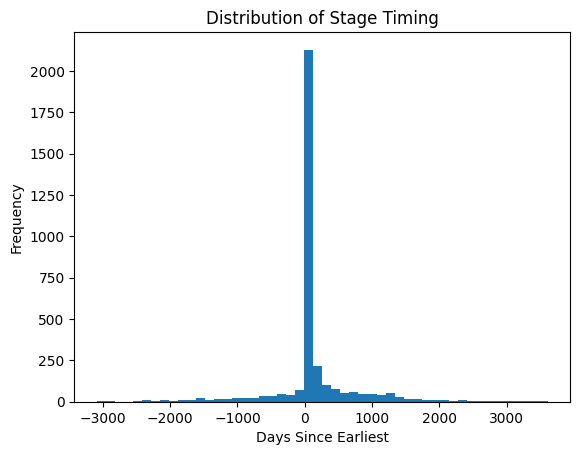

In [11]:
plt.hist(staging['most_recent_stage_date'], bins=50)
plt.title('Distribution of Stage Timing')
plt.xlabel('Days Since Earliest')
plt.ylabel('Frequency')
plt.show()

### Understanding When Staging Occurs

We create a new variable, `days_from_stage`, to measure where each claim occurs relative to the patient's most recent staging date.

- `days_since_earliest_dt` represents time since the patient's first observed claim (day 0).
- `most_recent_stage_date` represents when the most recent cancer stage was recorded.

By subtracting these values, we can see whether a claim happened **before or after the staging event**.

### Distribution of Staging Timing

The summary statistics and histogram show when staging tends to occur in the patient's timeline.

Key observations:
- The **median staging time is ~45 days** after the earliest observed claim.
- Most staging events occur **relatively early in the timeline**.
- Some negative values appear, meaning staging may have occurred **before our earliest recorded claim**.
- A small number of cases show staging much later in the timeline.

### Why This Matters

Understanding when staging occurs helps us align patients in time when modeling **utilization and cost trajectories**. It also helps us identify whether staging typically happens **near diagnosis or later during treatment progression**.

In [13]:
staging['most_recent_stage_date'].quantile([0.25, 0.5, 0.75])

0.25     10.0
0.50     45.0
0.75    125.0
Name: most_recent_stage_date, dtype: float64

In [14]:
staging['final_stage_simple'].value_counts()

final_stage_simple
I      1770
II      633
III     596
IV      393
Name: count, dtype: int64

In [15]:
stage_daily_cost = (
    claims_merged
    .groupby(['days_since_earliest_dt', 'final_stage_simple'])['c_allowed']
    .mean()
    .reset_index()
)

stage_daily_cost

,days_since_earliest_dt,final_stage_simple,c_allowed
0,-366,I,115.794936
1,-366,II,94.114158
2,-366,III,38.475358
3,-366,IV,80.484616
4,-365,I,72.802923
...,...,...,...
15971,3801,I,342.492584
15972,3806,I,3.960718
15973,3809,I,96.851826
15974,3813,I,136.434479


### Stage Timing and Stage Distribution

We first examine when staging typically occurs in the patient timeline.

- 25th percentile: **10 days**
- Median: **45 days**
- 75th percentile: **125 days**

This confirms that **most staging events happen early** relative to the first observed claim.

Next, we check the distribution of cancer stages in the dataset:

- **Stage I:** 1,770 patients  
- **Stage II:** 633 patients  
- **Stage III:** 596 patients  
- **Stage IV:** 393 patients  

Early-stage cancers make up the majority of the dataset.

### Preparing Cost Trajectories by Stage

To begin modeling utilization trajectories, we compute the **average allowed cost (`c_allowed`) for each day and stage group**.

We group the data by:
- `days_since_earliest_dt` → time in the patient timeline  
- `final_stage_simple` → simplified cancer stage (I–IV)

This produces a dataset where each row represents the **average daily cost at a specific point in time for a given cancer stage**.

This structure allows us to later visualize and compare **cost trajectories across cancer stages over time.**

In [16]:
pivot = stage_daily_cost.pivot(
    index='days_since_earliest_dt',
    columns='final_stage_simple',
    values='c_allowed'
)

In [17]:
pivot = pivot[pivot.index <= 2000]

In [18]:
pivot_rolling = pivot.rolling(window=30, min_periods=1).mean()

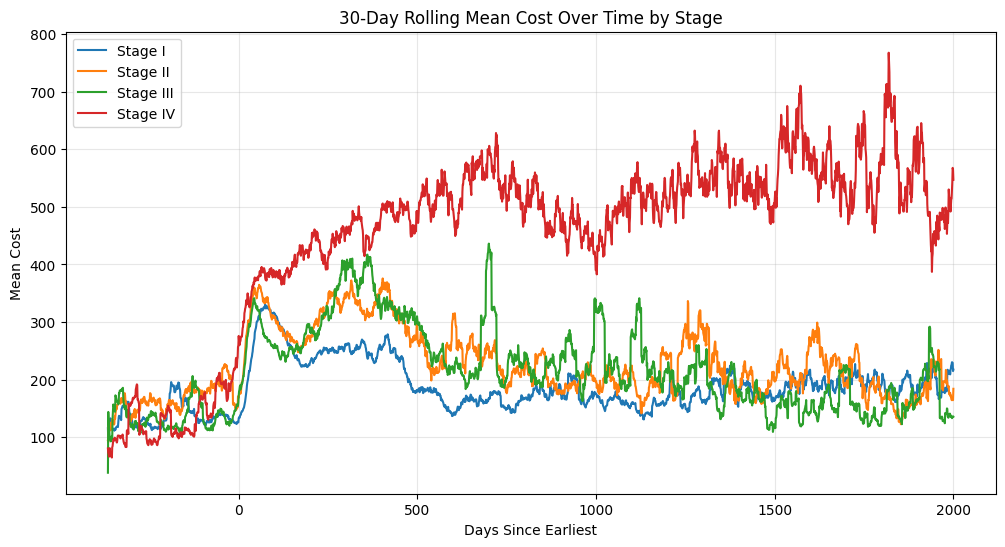

In [19]:
plt.figure(figsize=(12, 6))

for stage in pivot_rolling.columns:
    plt.plot(
        pivot_rolling.index,
        pivot_rolling[stage],
        label=f"Stage {stage}"
    )

plt.title("30-Day Rolling Mean Cost Over Time by Stage")
plt.xlabel("Days Since Earliest")
plt.ylabel("Mean Cost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Cost Trajectories by Cancer Stage

We reshape the data so that each row represents a **day in the patient timeline** and each column represents a **cancer stage (I–IV)**. This allows us to track how average costs change over time for each stage.

To reduce noise in daily claims data, we apply a **30-day rolling average** to smooth the cost trends.

We also limit the timeline to the first **2000 days** to focus on the main treatment window and avoid extreme long-tail values.

### Key Observations

- **Stage IV patients consistently have the highest costs**, reflecting more intensive treatment.
- **Stages II and III show moderate cost levels**, with some spikes likely tied to treatment events.
- **Stage I has the lowest overall costs**, which is expected for earlier-stage disease.
- Costs tend to **rise around the early part of the timeline**, which may correspond to diagnosis and initial treatment.

### Why This Matters

These trajectories give an initial view of how **utilization and costs evolve over time across cancer stages**. This helps us evaluate whether the data follows the **initial–continuing–terminal cost pattern** commonly described in the literature.

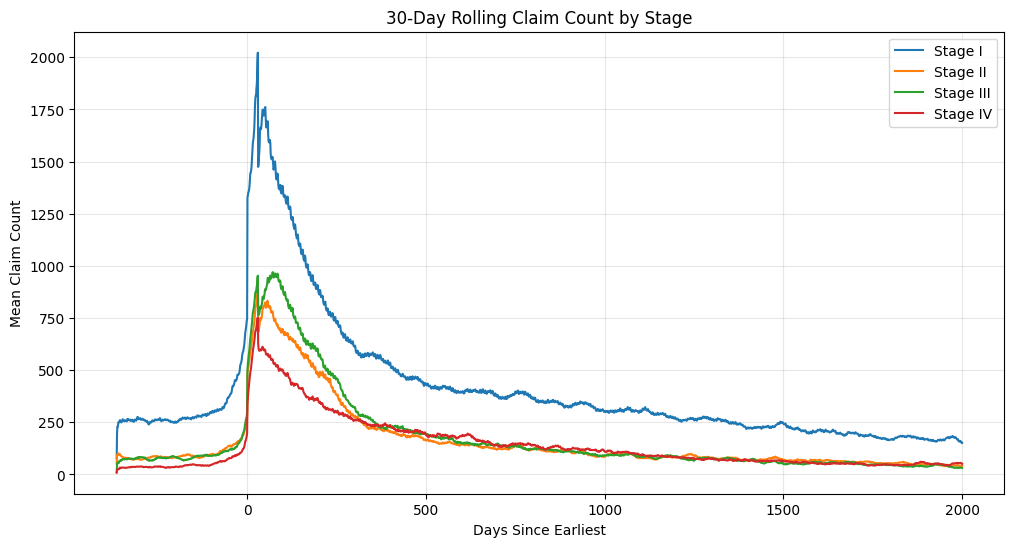

In [20]:
stage_daily_claims = (
    claims_merged
    .groupby(['days_since_earliest_dt', 'final_stage_simple'])
    .size()
    .reset_index(name='claim_count')
)

pivot_claims = stage_daily_claims.pivot(
    index='days_since_earliest_dt',
    columns='final_stage_simple',
    values='claim_count'
)

pivot_claims = pivot_claims[pivot_claims.index <= 2000]

pivot_claims_rolling = pivot_claims.rolling(30, min_periods=1).mean()

plt.figure(figsize=(12, 6))

for stage in pivot_claims_rolling.columns:
    plt.plot(
        pivot_claims_rolling.index,
        pivot_claims_rolling[stage],
        label=f"Stage {stage}"
    )

plt.title("30-Day Rolling Claim Count by Stage")
plt.xlabel("Days Since Earliest")
plt.ylabel("Mean Claim Count")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Claim Volume Trajectories by Stage

Next, we examine **utilization directly** by looking at the number of claims over time rather than cost.

We count the number of claims for each **day and stage group**, then reshape the data so each stage (I–IV) becomes a separate time series. Similar to the cost analysis, we apply a **30-day rolling average** to smooth daily fluctuations.

### Key Observations

- All stages show a **large spike in claim volume around day 0**, which likely corresponds to the **initial diagnosis and treatment period**.
- After this spike, claim activity **declines steadily over time**.
- **Stage I has the highest claim volume**, likely because early-stage cancers are the most common in the dataset.
- Later stages show **lower overall volume but still sustained utilization** over time.

### Why This Matters

Looking at **claim counts instead of costs** helps us understand the **intensity of healthcare utilization**. Together with the cost trajectories, this provides a clearer picture of how treatment activity evolves over time across cancer stages.

In [21]:
# Filter to Stage IV patients
stage_iv = claims_merged[
    claims_merged['final_stage_simple'] == 'IV'
]

# Identify unique Stage IV patients
stage_iv_patients = (
    stage_iv[['member_number', 'most_recent_stage_date']]
    .drop_duplicates()
)

# Define cohorts
early_patients = stage_iv_patients[
    stage_iv_patients['most_recent_stage_date'] < 30
]['member_number']

late_patients = stage_iv_patients[
    stage_iv_patients['most_recent_stage_date'] > 180
]['member_number']

print("Early Stage IV patients:", early_patients.nunique())
print("Late Stage IV patients:", late_patients.nunique())

Early Stage IV patients: 182
Late Stage IV patients: 138


In [22]:
early_claims = stage_iv[
    stage_iv['member_number'].isin(early_patients)
]

late_claims = stage_iv[
    stage_iv['member_number'].isin(late_patients)
]

In [23]:
early_daily = (
    early_claims
    .groupby('days_since_earliest_dt')
    .agg(
        total_cost=('c_allowed', 'sum'),
        unique_members=('member_number', 'nunique')
    )
    .reset_index()
)

early_daily['cost_per_patient'] = (
    early_daily['total_cost'] /
    early_daily['unique_members']
)

In [24]:
late_daily = (
    late_claims
    .groupby('days_since_earliest_dt')
    .agg(
        total_cost=('c_allowed', 'sum'),
        unique_members=('member_number', 'nunique')
    )
    .reset_index()
)

late_daily['cost_per_patient'] = (
    late_daily['total_cost'] /
    late_daily['unique_members']
)

In [25]:
max_day = 2000

early_daily = early_daily[early_daily['days_since_earliest_dt'] <= max_day]
late_daily = late_daily[late_daily['days_since_earliest_dt'] <= max_day]

In [26]:
early_daily['rolling_cost'] = (
    early_daily['cost_per_patient']
    .rolling(30, min_periods=1)
    .mean()
)

late_daily['rolling_cost'] = (
    late_daily['cost_per_patient']
    .rolling(30, min_periods=1)
    .mean()
)

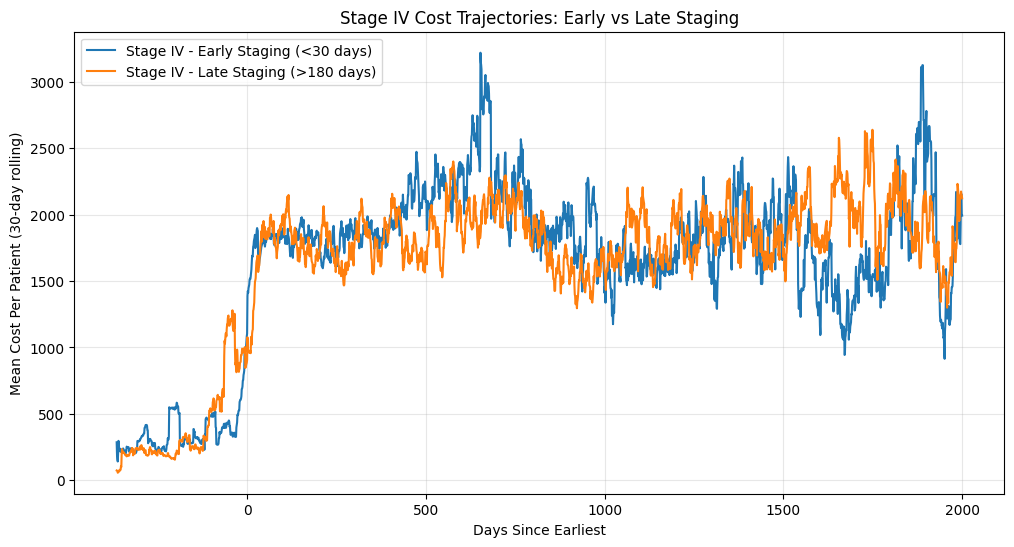

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    early_daily['days_since_earliest_dt'],
    early_daily['rolling_cost'],
    label='Stage IV - Early Staging (<30 days)'
)

plt.plot(
    late_daily['days_since_earliest_dt'],
    late_daily['rolling_cost'],
    label='Stage IV - Late Staging (>180 days)'
)

plt.title("Stage IV Cost Trajectories: Early vs Late Staging")
plt.xlabel("Days Since Earliest")
plt.ylabel("Mean Cost Per Patient (30-day rolling)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

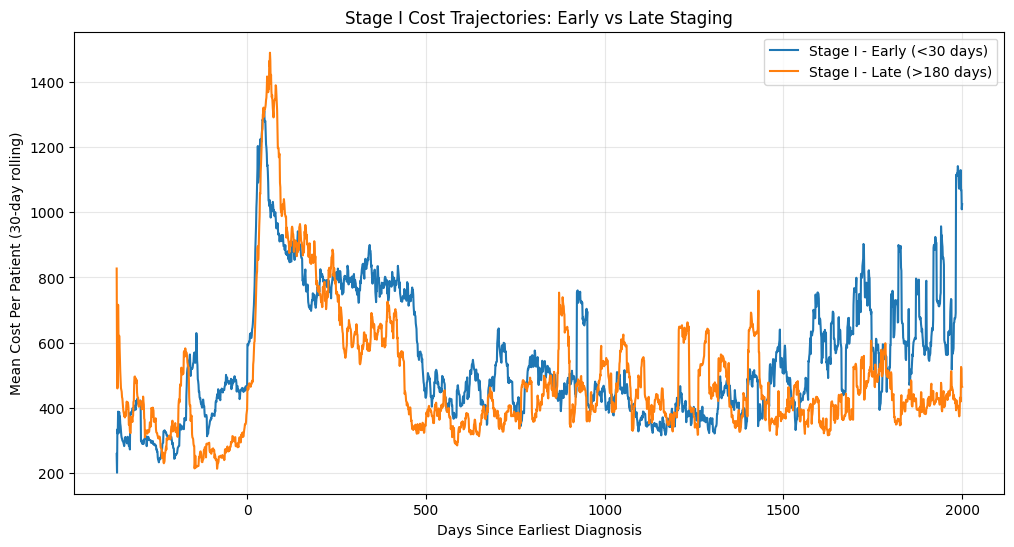

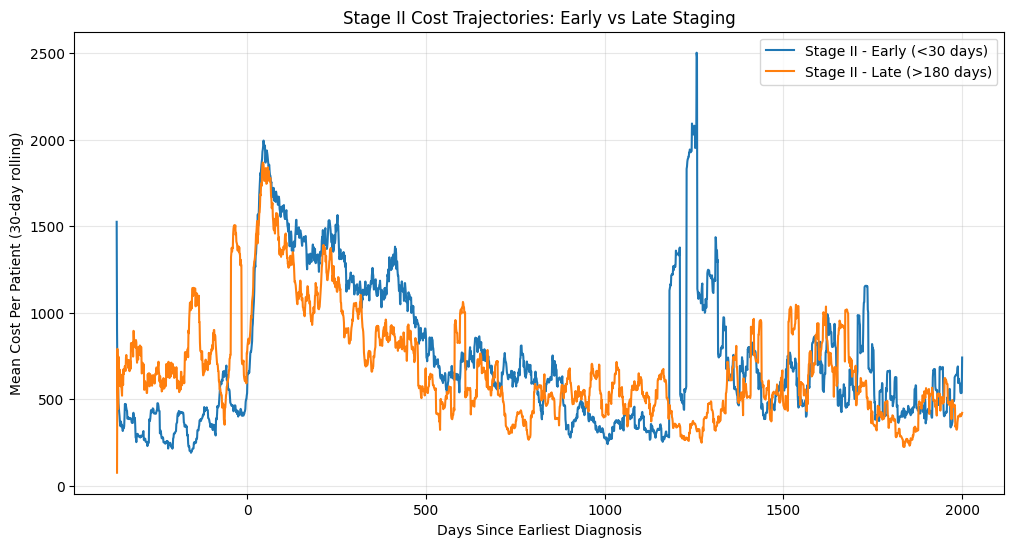

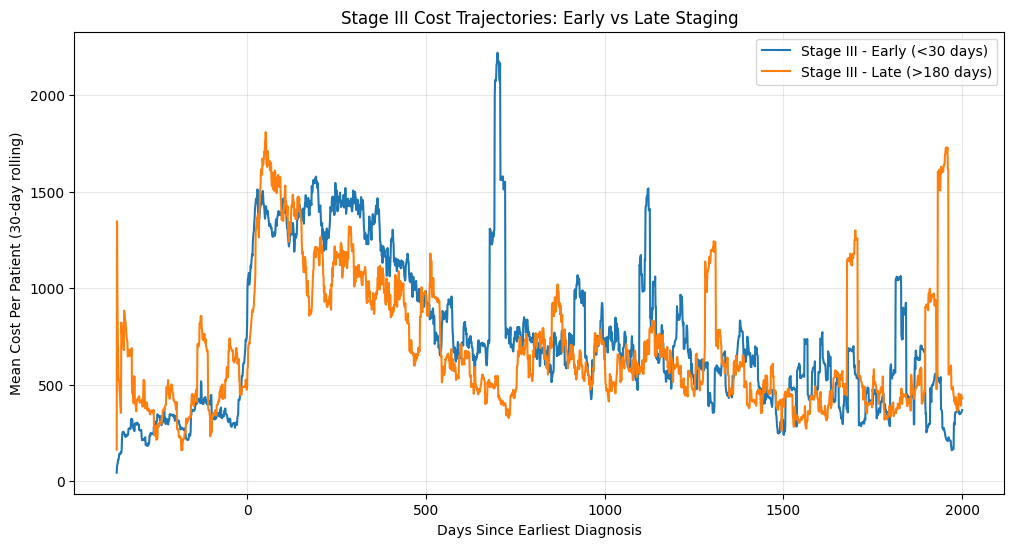

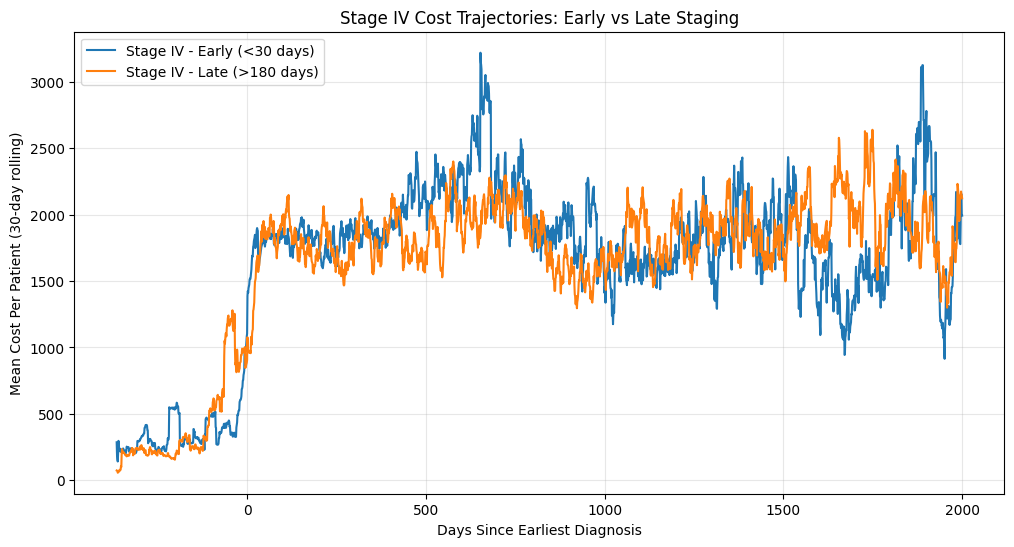

In [28]:
stages = ['I', 'II', 'III', 'IV']
max_day = 2000

for stage in stages:

    stage_df = claims_merged[
        claims_merged['final_stage_simple'] == stage
    ]

    stage_patients = (
        stage_df[['member_number','most_recent_stage_date']]
        .drop_duplicates()
    )

    early_patients = stage_patients[
        stage_patients['most_recent_stage_date'] < 30
    ]['member_number']

    late_patients = stage_patients[
        stage_patients['most_recent_stage_date'] > 180
    ]['member_number']

    early_claims = stage_df[
        stage_df['member_number'].isin(early_patients)
    ]

    late_claims = stage_df[
        stage_df['member_number'].isin(late_patients)
    ]

    early_daily = (
        early_claims
        .groupby('days_since_earliest_dt')
        .agg(
            total_cost=('c_allowed','sum'),
            unique_members=('member_number','nunique')
        )
        .reset_index()
    )

    early_daily['cost_per_patient'] = (
        early_daily['total_cost'] /
        early_daily['unique_members']
    )

    late_daily = (
        late_claims
        .groupby('days_since_earliest_dt')
        .agg(
            total_cost=('c_allowed','sum'),
            unique_members=('member_number','nunique')
        )
        .reset_index()
    )

    late_daily['cost_per_patient'] = (
        late_daily['total_cost'] /
        late_daily['unique_members']
    )

    early_daily = early_daily[
        early_daily['days_since_earliest_dt'] <= max_day
    ]

    late_daily = late_daily[
        late_daily['days_since_earliest_dt'] <= max_day
    ]

    early_daily['rolling_cost'] = (
        early_daily['cost_per_patient']
        .rolling(30, min_periods=1)
        .mean()
    )

    late_daily['rolling_cost'] = (
        late_daily['cost_per_patient']
        .rolling(30, min_periods=1)
        .mean()
    )

    plt.figure(figsize=(12,6))

    plt.plot(
        early_daily['days_since_earliest_dt'],
        early_daily['rolling_cost'],
        label=f"Stage {stage} - Early (<30 days)"
    )

    plt.plot(
        late_daily['days_since_earliest_dt'],
        late_daily['rolling_cost'],
        label=f"Stage {stage} - Late (>180 days)"
    )

    plt.title(f"Stage {stage} Cost Trajectories: Early vs Late Staging")
    plt.xlabel("Days Since Earliest Diagnosis")
    plt.ylabel("Mean Cost Per Patient (30-day rolling)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

### Comparing Stage IV Cost Trajectories: Early vs Late Staging

To explore differences within Stage IV patients, we split the group into two cohorts based on **when staging occurred in the patient timeline**.

- **Early staging:** staging recorded within **30 days** of the first observed claim  
- **Late staging:** staging recorded **more than 180 days** after the first observed claim  

This creates two groups:
- **182 early-staged Stage IV patients**
- **138 late-staged Stage IV patients**

### Cost Per Patient Over Time

For each group, we calculate:

- **Total daily cost**
- **Number of unique patients active that day**
- **Cost per patient = total cost ÷ active patients**

We then smooth the series using a **30-day rolling average** to reduce noise.

### Key Observations

- Both groups show a **sharp increase in costs near the early treatment period**, likely tied to intensive care around diagnosis or progression.
- Early-staged Stage IV patients tend to show **slightly higher peaks in cost**, possibly reflecting more aggressive treatment earlier in the timeline.
- Late-staged patients have **more gradual cost increases**, suggesting staging may occur after a longer treatment history.

### Why This Matters

This comparison helps identify **different utilization patterns within the same stage group**. Patients who reach Stage IV early in their timeline may follow a different treatment and cost trajectory than those who progress to Stage IV later.

### Interpretation of Early vs Late Staging Cost Trajectories

To understand how staging timing affects healthcare utilization, we compare patients who were staged **early (<30 days)** versus those staged **later (>180 days)** across Stage I–III disease. The trajectories represent the **30-day rolling average cost per patient over time since earliest diagnosis**.

#### Stage I

For Stage I disease, early and late staging trajectories follow broadly similar patterns, with both groups experiencing a noticeable spike in costs around the time of diagnosis and initial treatment. This early peak likely corresponds to **diagnostic imaging, surgery, and initial treatment planning**. After this period, costs decline and stabilize into a relatively low and consistent level of utilization. 

However, patients staged early tend to maintain **slightly higher costs later in the timeline**, particularly after roughly 1500 days. This may reflect **ongoing surveillance, follow-up imaging, or additional treatment episodes**. Overall, the similarity between the curves suggests that for Stage I disease, **timing of staging does not dramatically alter long-term cost trajectories**, as treatment pathways are relatively standardized.

---

#### Stage II

Stage II patients exhibit **larger cost variation** than Stage I. Both early and late staging groups experience a pronounced spike shortly after diagnosis, reflecting the more intensive treatment typically required at this stage (e.g., combinations of surgery, chemotherapy, and radiation).

Early staged patients show **higher initial and mid-term costs**, including a large spike around the middle of the timeline, which may correspond to **additional treatment cycles, complications, or recurrence management**. Late staged patients, in contrast, tend to have **more moderate costs over time**, though they still exhibit intermittent spikes.

These patterns suggest that Stage II care may involve **more heterogeneous treatment pathways**, where timing of staging may correlate with differences in treatment intensity or follow-up care.

---

#### Stage III

Stage III trajectories show **substantially higher variability and volatility** compared to earlier stages. Both early and late staging groups experience significant spikes around the time of diagnosis, reflecting aggressive treatment regimens common for advanced disease.

Early staged patients show **large intermittent spikes in cost throughout the timeline**, indicating periods of intensive care such as additional therapy cycles, hospitalizations, or treatment complications. Late staged patients show a similar pattern but with somewhat lower sustained costs over time.

Overall, Stage III disease demonstrates that **cost trajectories become increasingly heterogeneous as disease severity increases**, with substantial fluctuations likely driven by complex treatment pathways, recurrence management, and complications.

---

### Key Takeaway

Across stages I–III, the cost trajectories share a common structure: a **large initial spike around diagnosis followed by a gradual decline and stabilization**. However, as stage increases, the **magnitude and volatility of costs increase**, reflecting the growing complexity of treatment. While early versus late staging shows some differences in specific cost spikes and long-term utilization patterns, the overall shape of the cost trajectory remains largely driven by **disease stage and treatment intensity**.

In [29]:
claims_merged['phase'] = np.select(
    [
        claims_merged['days_since_earliest_dt'] <= 180,
        claims_merged['days_since_earliest_dt'] <= 1000
    ],
    ['initial', 'continuing'],
    default='late'
)

# Aggregate to patient level
patient_summary = (
    claims_merged
    .groupby('member_number')
    .agg(
        cancer_type=('cancer_type', 'first'),
        stage=('final_stage_simple', 'first'),
        time_to_stage=('most_recent_stage_date', 'first'),
        followup_time=('days_since_earliest_dt', 'max'),
        total_cost=('c_allowed', 'sum')
    )
    .reset_index()
)

In [30]:
phase_costs = (
    claims_merged
    .groupby(['member_number', 'phase'])['c_allowed']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

patient_summary = patient_summary.merge(
    phase_costs,
    on='member_number',
    how='left'
)

In [31]:
duration_summary = (
    patient_summary
    .groupby(['cancer_type', 'stage'])
    .agg(
        mean_time_to_stage=('time_to_stage', 'mean'),
        median_time_to_stage=('time_to_stage', 'median'),
        mean_followup=('followup_time', 'mean'),
        count=('member_number', 'count')
    )
    .reset_index()
)

duration_summary

,cancer_type,stage,mean_time_to_stage,median_time_to_stage,mean_followup,count
0,breast,I,116.771893,55.0,1522.992232,1416
1,breast,II,153.826667,52.0,1552.709333,375
2,breast,III,288.392857,58.5,1605.314286,140
3,breast,IV,518.263636,197.0,1530.109091,110
4,colorectal,I,123.802198,53.0,1560.538462,91
5,colorectal,II,-2.695652,36.0,1172.668478,184
6,colorectal,III,10.767516,28.0,1275.407643,314
7,colorectal,IV,319.912281,55.5,1099.026316,114
8,lung,I,73.171103,6.0,1197.593156,263
9,lung,II,-33.621622,26.0,1053.418919,74


### Defining Treatment Phases and Patient-Level Summary

To better understand cost patterns over time, we divide each patient’s timeline into three phases based on days since the earliest claim:

- **Initial phase:** first 180 days  
- **Continuing phase:** days 181–1000  
- **Late phase:** after 1000 days  

These phases roughly correspond to the **initial treatment period, ongoing care, and later-stage management**, which are commonly used in cancer cost studies.

### Aggregating to the Patient Level

We then summarize key information for each patient:

- **Cancer type**
- **Final recorded stage**
- **Time until staging**
- **Total follow-up time**
- **Total cost across all claims**

We also calculate **total costs within each phase** (initial, continuing, late).  
This gives a clearer picture of **how costs accumulate over the course of a patient’s disease timeline**.

- **Follow-up time:** how long a patient appears in the dataset after their first claim (i.e., the length of time we observe their healthcare activity).

### Stage and Cancer-Type Duration Summary

Finally, we aggregate these patient-level metrics by **cancer type and stage** to understand how trajectories differ across groups.

For each group we calculate:
- **Mean and median time until staging**
- **Average follow-up duration**
- **Number of patients**

### Key Observations

- **Breast cancer Stage IV patients have the longest time to staging**, suggesting progression may occur later in the observed timeline.
- **Early-stage cancers generally show shorter time to staging**, consistent with earlier diagnosis.
- Follow-up times are relatively long across groups (~3–4 years), which provides enough data to study **long-term utilization trajectories**.

### Why This Matters

This patient-level summary helps establish the **typical timelines for different cancers and stages**, which is useful when building models of **cancer utilization and cost trajectories**.

In [32]:
patient_summary['initial_rate'] = (
    patient_summary['initial'] / 180
)

patient_summary['continuing_rate'] = (
    patient_summary['continuing'] / 820  # 1000-180
)

patient_summary['late_rate'] = (
    patient_summary['late'] / 
    np.maximum(patient_summary['followup_time'] - 1000, 1)
)

In [33]:
from sklearn.preprocessing import StandardScaler

features = [
    'time_to_stage',
    'followup_time',
    'initial_rate',
    'continuing_rate',
    'late_rate'
]

X = patient_summary[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

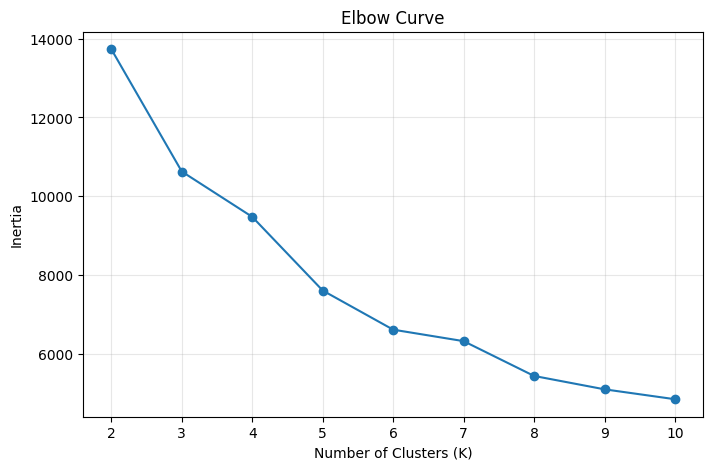

In [34]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Curve")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.show()

### Preparing Features for Clustering

Next, we create features that summarize each patient’s cost trajectory.

We convert phase costs into **rates** so patients with different follow-up lengths can be compared fairly:

- **Initial rate:** cost during the first 180 days divided by 180  
- **Continuing rate:** cost from day 181–1000 divided by 820 days  
- **Late rate:** cost after day 1000 divided by the number of observed days in that period  

These rates represent the **average daily spending intensity** during each phase of care.

We then construct a feature set for each patient that includes:

- **Time to stage** – how long it took for staging to occur  
- **Follow-up time** – how long the patient appears in the data  
- **Initial rate** – average cost intensity early in treatment  
- **Continuing rate** – average cost intensity during ongoing care  
- **Late rate** – average cost intensity later in the timeline  

Before clustering, we standardize the variables so that features with larger numeric scales (like time) do not dominate the clustering.

### Choosing the Number of Clusters

We use the **elbow method** with K-Means clustering to determine a reasonable number of clusters.

The plot shows how **inertia (within-cluster variance)** changes as the number of clusters increases.  
As K increases, inertia decreases because clusters fit the data more closely.

We look for a point where the improvement starts to level off — the **“elbow”** — which suggests a good balance between model simplicity and explanatory power.

This helps determine how many **distinct cancer utilization trajectory profiles** may exist in the dataset.

In [35]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
patient_summary['cluster'] = kmeans.fit_predict(X_scaled)

In [36]:
cluster_summary = (
    patient_summary
    .groupby('cluster')
    .agg(
        count=('member_number', 'count'),
        mean_time_to_stage=('time_to_stage', 'mean'),
        mean_total_cost=('total_cost', 'mean'),
        mean_initial=('initial_rate', 'mean'),
        mean_continuing=('continuing_rate', 'mean'),
        mean_late=('late_rate', 'mean')
    )
)

cluster_summary

,count,mean_time_to_stage,mean_total_cost,mean_initial,mean_continuing,mean_late
cluster,,,,,,
0,1134,100.954145,154732.911534,294.792924,55.926726,50.137921
1,277,141.018051,776902.188661,1053.801323,478.294213,284.751128
2,295,1523.722034,191431.071360,148.862241,49.981863,79.853725
3,1686,-112.762159,99097.398539,323.932790,48.150515,7.116915


### Identifying Utilization Trajectory Clusters

Using the selected features, we apply **K-Means clustering (K = 4)** to group patients with similar cost trajectories over time.

Each patient is assigned to one of four clusters based on:
- time to stage
- follow-up time
- initial cost rate
- continuing cost rate
- late cost rate

This groups together patients who have **similar treatment intensity patterns across the different phases of care**.

### Cluster Summary

The table above summarizes the average characteristics of patients in each cluster.

Key patterns:

- **Cluster 1** shows extremely high costs across all phases, especially during the initial treatment period. These likely represent **high-intensity treatment trajectories**.
- **Cluster 0** has moderate initial costs but much lower continuing and late costs, suggesting **front-loaded treatment followed by lower utilization**.
- **Cluster 2** has a very long time to stage, which may represent **patients whose staging occurred much later in their observed timeline**.
- **Cluster 3** has relatively lower total costs overall and the lowest late-phase spending.

### Why This Matters

Clustering helps identify **distinct utilization profiles** that may not be visible when looking only at stage or cancer type.  

These clusters can help reveal different **treatment pathways, remission patterns, or progression timelines**, which supports the broader goal of modeling **cancer utilization trajectories**.

In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

patient_summary['PC1'] = X_pca[:, 0]
patient_summary['PC2'] = X_pca[:, 1]

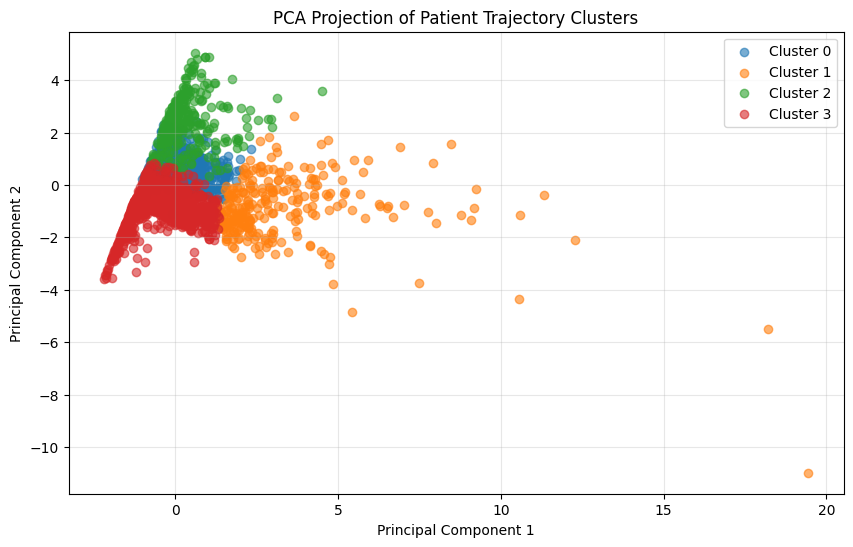

In [38]:
plt.figure(figsize=(10,6))

for cluster_id in sorted(patient_summary['cluster'].unique()):
    subset = patient_summary[patient_summary['cluster'] == cluster_id]
    
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=f'Cluster {cluster_id}',
        alpha=0.6
    )

plt.title("PCA Projection of Patient Trajectory Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

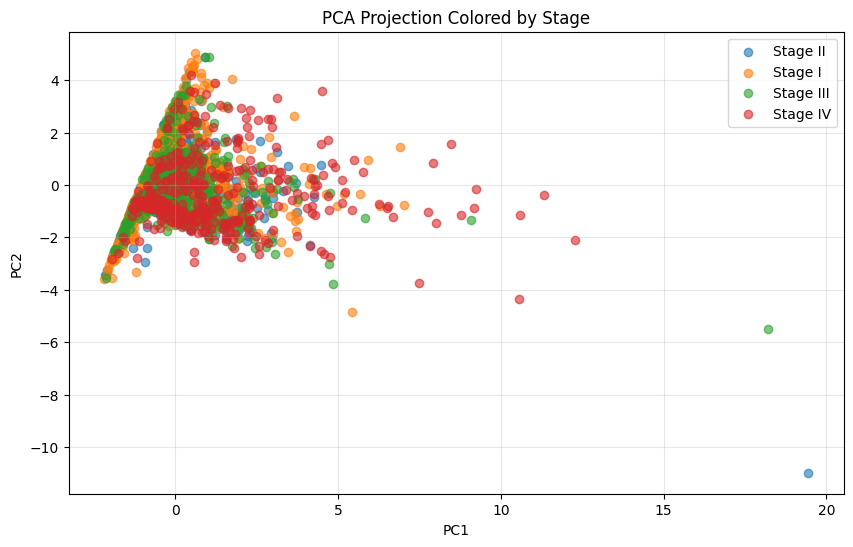

In [39]:
plt.figure(figsize=(10,6))

for stage in patient_summary['stage'].unique():
    subset = patient_summary[patient_summary['stage'] == stage]
    
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=f'Stage {stage}',
        alpha=0.6
    )

plt.title("PCA Projection Colored by Stage")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [40]:
print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.35966977 0.28370733]


In [41]:
from sklearn.metrics import pairwise_distances

distances = pairwise_distances(X_scaled, kmeans.cluster_centers_)
min_distance = distances.min(axis=1)

patient_summary['distance_from_cluster'] = min_distance

In [42]:
threshold = patient_summary['distance_from_cluster'].quantile(0.99)

outliers = patient_summary[
    patient_summary['distance_from_cluster'] > threshold
]

outliers

,member_number,cancer_type,stage,time_to_stage,followup_time,total_cost,continuing,initial,late,initial_rate,continuing_rate,late_rate,cluster,PC1,PC2,distance_from_cluster
165,A182,lung,IV,-6.0,200,4.597808e+05,5.861400e+03,4.539193e+05,0.000000e+00,2521.774167,7.148049,0.000000,1,2.019271,-2.740726,5.227628
328,A354,colorectal,I,5.0,326,9.617151e+05,8.168693e+04,8.800282e+05,0.000000e+00,4889.045333,99.618207,0.000000,1,5.435682,-4.845198,10.258010
377,A406,breast,I,226.0,1410,4.894968e+05,4.887910e+04,2.386371e+04,4.167540e+05,132.576167,59.608657,1016.473070,1,2.944915,1.055254,6.010919
471,A506,breast,IV,346.0,2666,3.780082e+06,1.074333e+06,2.572292e+05,2.448520e+06,1429.051111,1310.161683,1469.700160,1,11.322671,-0.395550,9.568157
497,A532,lung,I,0.0,1071,9.684497e+05,8.199589e+05,7.244423e+04,7.604649e+04,402.467944,999.949939,1071.077324,1,7.022515,-0.773943,6.393030
676,A728,colorectal,III,-659.0,1019,7.213601e+04,4.616004e+04,4.430190e+03,2.154578e+04,24.612167,56.292727,1133.988372,1,2.847770,0.134763,6.901217
677,A729,breast,III,203.0,469,9.312367e+05,2.743526e+05,6.568840e+05,0.000000e+00,3649.355799,334.576374,0.000000,1,4.858477,-3.769401,6.987066
748,A803,colorectal,IV,342.0,1416,1.422139e+06,6.997837e+05,3.393934e+05,3.829617e+05,1885.519056,853.394752,920.581051,1,8.002516,-1.446735,5.292081
900,A965,breast,III,14.0,1187,2.961593e+06,1.979467e+06,7.298412e+05,2.522854e+05,4054.673128,2413.984002,1349.119746,1,18.203345,-5.483619,15.779497
982,B050,colorectal,IV,805.0,1021,1.122526e+06,8.375210e+05,2.593622e+05,2.564285e+04,1440.901023,1021.367098,1221.087908,1,9.185301,-0.866173,7.254344


In [43]:
pd.crosstab(patient_summary['cluster'], patient_summary['cancer_type'], normalize='index')

cancer_type,breast,colorectal,lung
cluster,,,
0,0.686067,0.192240,0.121693
1,0.512635,0.155235,0.332130
2,0.759322,0.132203,0.108475
3,0.532028,0.239027,0.228944


### Visualizing Patient Trajectory Clusters

To better understand how the clusters relate to one another, we use **Principal Component Analysis (PCA)** to project the multidimensional feature space into two dimensions.

The clustering algorithm was trained on five features:

- time to stage  
- follow-up time  
- initial cost rate  
- continuing cost rate  
- late cost rate  

Because these variables exist in a **five-dimensional space**, it is difficult to directly visualize how patients group together. PCA addresses this by transforming the original features into new variables called **principal components**, which capture the directions of greatest variation in the data.

The first two principal components explain approximately **64% of the total variance** in the dataset (PC1 ≈ 36%, PC2 ≈ 28%). While this does not capture all variability, it preserves enough structure to meaningfully visualize how patients are distributed.

When plotting the PCA projection colored by cluster, several patterns emerge:

- **Cluster 1 separates strongly along the first principal component**, indicating that this group has much higher overall cost intensity compared to the rest of the population.
- The remaining clusters occupy more overlapping regions of the PCA space, suggesting that their differences are more subtle and driven by combinations of cost timing and follow-up length rather than a single dominant factor.
- The overall triangular structure of the plot reflects trade-offs between the different cost phases (initial, continuing, and late).

Together, this visualization confirms that the clustering algorithm is identifying **distinct utilization trajectory profiles**, even though some overlap between clusters naturally exists in complex healthcare data.

---

### Comparing Clusters to Cancer Stage

To determine whether the clusters simply reflect **cancer stage**, we also visualize the PCA projection with points colored by stage (I–IV).

If stage were the primary driver of cost trajectories, we would expect to see clear regions dominated by a single stage. Instead, the stage groups are **heavily intermixed across the PCA space**, meaning patients with similar stages can have very different utilization patterns.

This suggests that **stage alone does not explain the trajectory clusters**. While stage certainly influences treatment intensity, other factors—such as treatment type, comorbidities, or cancer biology—likely contribute to the observed cost patterns.

---

### Evaluating the Role of Cancer Type

To further investigate potential drivers of the clusters, we examine the distribution of **cancer types within each cluster**.

The normalized cross-tabulation shows the proportion of patients with each cancer type in every cluster:

| Cluster | Breast | Colorectal | Lung |
|-------|-------|-------|------|
| 0 | ~69% | ~19% | ~12% |
| 1 | ~51% | ~16% | ~33% |
| 2 | ~76% | ~13% | ~11% |
| 3 | ~53% | ~24% | ~23% |

Several patterns emerge:

- **Breast cancer dominates most clusters**, reflecting its prevalence in the dataset.
- **Cluster 1 has a much larger share of lung cancer patients**, which aligns with its substantially higher cost intensity and may reflect the use of expensive targeted therapies or immunotherapies.
- **Cluster 3 shows a more balanced distribution across cancer types**, suggesting that this cluster may reflect more general utilization patterns rather than disease-specific pathways.

Overall, this analysis suggests that **cancer type may partially influence trajectory clusters**, although it does not appear to fully determine them.

---

### Identifying Outlier Patients

Finally, we compute the **distance between each patient and the centroid of their assigned cluster**. This measures how typical a patient is relative to others in the same cluster.

Patients whose distance falls within the **top 1% of the distribution** are flagged as potential outliers.

These outliers may represent:

- unusually high-cost treatment trajectories  
- atypical disease progression timelines  
- rare treatment pathways  
- or possible data anomalies

Investigating these cases can help identify **extreme utilization patterns**, which may provide valuable insights into high-cost care scenarios or unusual treatment pathways.

In [44]:
pd.crosstab(patient_summary['cluster'], patient_summary['stage'])

stage,I,II,III,IV
cluster,,,,
0,710,201,177,46
1,60,57,54,106
2,151,53,40,51
3,849,322,325,190


In [45]:
pd.crosstab(patient_summary['cluster'], patient_summary['cancer_type'])

cancer_type,breast,colorectal,lung
cluster,,,
0,778,218,138
1,142,43,92
2,224,39,32
3,897,403,386


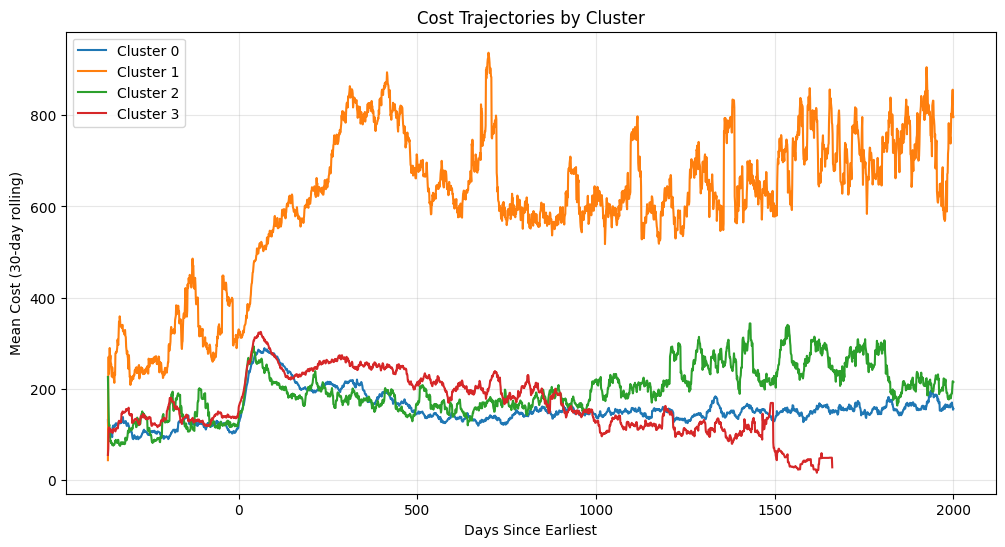

In [46]:
cluster_daily_cost = (
    claims_merged
    .merge(patient_summary[['member_number', 'cluster']],
           on='member_number')
    .groupby(['days_since_earliest_dt', 'cluster'])['c_allowed']
    .mean()
    .reset_index()
)

pivot_cluster = cluster_daily_cost.pivot(
    index='days_since_earliest_dt',
    columns='cluster',
    values='c_allowed'
)

pivot_cluster = pivot_cluster[pivot_cluster.index <= 2000]

pivot_cluster_rolling = pivot_cluster.rolling(30, min_periods=1).mean()

plt.figure(figsize=(12,6))

for c in pivot_cluster_rolling.columns:
    plt.plot(
        pivot_cluster_rolling.index,
        pivot_cluster_rolling[c],
        label=f'Cluster {c}'
    )

plt.title("Cost Trajectories by Cluster")
plt.xlabel("Days Since Earliest")
plt.ylabel("Mean Cost (30-day rolling)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Examining Stage and Cancer Type Across Clusters

To further understand what may be driving the trajectory clusters, we compare cluster membership with both **cancer stage** and **cancer type**.

The cross-tabulation of clusters and stage shows that **all stages appear in every cluster**, although the proportions differ. For example, Cluster 0 and Cluster 3 contain a large number of **Stage I patients**, while Cluster 1 has a relatively higher share of **Stage IV cases** compared to the other clusters. This suggests that later-stage disease may contribute to the higher treatment intensity seen in Cluster 1, but stage alone does not determine cluster membership.

Similarly, when examining the distribution of **cancer types**, breast cancer appears most frequently across all clusters, which is expected given its larger representation in the dataset. However, Cluster 1 contains a noticeably larger proportion of **lung cancer patients**, which may partially explain its higher cost trajectory since lung cancer treatments often involve expensive targeted therapies or immunotherapies. Cluster 3 shows a more balanced mix of breast, colorectal, and lung cancers, suggesting it may capture broader utilization patterns rather than disease-specific pathways.

Overall, these comparisons indicate that **both stage and cancer type likely influence cost trajectories**, but neither variable alone fully explains the clusters. Instead, the clustering appears to capture a combination of disease characteristics and treatment intensity over time.

---

### Visualizing Cost Trajectories by Cluster

To better interpret the clusters, we examine how **average healthcare costs evolve over time** for patients in each group.

We merge the cluster assignments back to the claims-level data and calculate the **mean allowed cost per day since the earliest observed claim** for each cluster. To reduce noise and highlight overall trends, we apply a **30-day rolling average** to smooth the trajectories.

The resulting plot reveals several distinct utilization patterns:

- **Cluster 1 shows consistently high spending across the entire timeline**, indicating a group of patients with sustained high treatment intensity. This aligns with earlier observations that this cluster has the highest average total costs.
  
- **Cluster 2 exhibits a gradual increase in spending later in the timeline**, suggesting patients whose treatment intensity rises over time, potentially reflecting disease progression or later-stage interventions.

- **Cluster 0 shows moderate but relatively stable costs**, indicating a more consistent and lower-intensity treatment pathway.

- **Cluster 3 starts with moderate spending that gradually declines**, which may represent patients who receive early treatment followed by reduced utilization in later periods.

These trajectory patterns provide a clearer interpretation of what the clustering algorithm has captured: **different temporal patterns of healthcare utilization**, rather than simply differences in total cost.

Together, these results support the idea that cancer care follows **multiple distinct cost pathways**, which may reflect variations in treatment strategies, disease progression, and patient-specific clinical factors.

### Cluster Summary and Interpretation

Based on the cost trajectories, feature averages, and distributions of stage and cancer type, we can assign descriptive labels to each cluster to help interpret the types of utilization patterns they represent. These labels are not definitive clinical categories, but rather **data-driven summaries of the typical cost trajectory observed within each group**.

**Cluster 0 — Moderate Early Treatment, Stable Long-Term Care**  
This cluster represents patients with moderate initial treatment intensity followed by relatively stable and lower continuing costs. Most patients in this group are **Stage I**, and breast cancer is the most common cancer type. The cost trajectory suggests patients who receive an initial round of treatment and then transition into lower-intensity follow-up care or maintenance therapy.

**Cluster 1 — High-Intensity Treatment Trajectory**  
Cluster 1 clearly represents the **highest-cost utilization profile**. Patients in this cluster have significantly higher costs across all phases of care, especially during the early treatment period. This group contains a larger share of **Stage IV cases** and a higher proportion of **lung cancer patients**, both of which are often associated with expensive systemic therapies. The cost trajectory shows sustained high spending across the timeline, indicating prolonged and intensive treatment.

**Cluster 2 — Delayed or Gradually Increasing Treatment Intensity**  
Patients in this cluster tend to have a **longer time to staging** and a cost trajectory that gradually increases later in the timeline. This may reflect cases where treatment intensifies over time due to disease progression or delayed diagnosis. Breast cancer again dominates the group, but the trajectory pattern distinguishes it from the more stable clusters.

**Cluster 3 — Early Treatment Followed by Declining Utilization**  
Cluster 3 shows relatively moderate early costs that gradually decline over time. While this cluster contains patients across all stages, it includes many early-stage cases. The trajectory may represent patients who undergo initial treatment—such as surgery or chemotherapy—followed by reduced healthcare utilization in later periods, possibly due to remission or completion of treatment.

### Key Takeaway

These clusters highlight that **cancer care does not follow a single cost trajectory**. Instead, patients tend to fall into a small number of distinct patterns characterized by different levels and timing of healthcare utilization. Stage and cancer type contribute to these patterns but do not fully explain them, suggesting that treatment pathways, disease progression, and other clinical factors likely play important roles in shaping utilization trajectories.

In [47]:
patient_summary.groupby('cluster')['followup_time'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,1134.0,2245.873016,571.898745,1030.0,1757.25,2208.0,2683.0,3629.0
1,277.0,1407.169675,774.220793,200.0,840.00,1206.0,1905.0,3617.0
2,295.0,2598.067797,1036.505866,72.0,1703.00,3068.0,3526.5,3819.0
3,1686.0,586.725979,399.616289,0.0,245.25,533.5,915.0,1632.0


In [48]:
cohort = claims_merged[
    (claims_merged['cancer_type'] == 'breast') &
    (claims_merged['final_stage_simple'] == 'II')
].copy()

In [49]:
cohort['member_number'].nunique()

375

In [50]:
def compute_patient_features(df):

    patient_features = []

    for pid, g in df.groupby('member_number'):

        g = g.sort_values('days_since_earliest_dt')

        time_to_stage = g['most_recent_stage_date'].iloc[0]
        followup = g['days_since_earliest_dt'].max()

        initial = g[g['days_since_earliest_dt'] <= 180]['c_allowed'].mean()
        continuing = g[
            (g['days_since_earliest_dt'] > 180) &
            (g['days_since_earliest_dt'] <= 1000)
        ]['c_allowed'].mean()

        late = g[
            g['days_since_earliest_dt'] >= (followup - 180)
        ]['c_allowed'].mean()

        total_cost = g['c_allowed'].sum()

        patient_features.append({
            'member_number': pid,
            'time_to_stage': time_to_stage,
            'followup': followup,
            'mean_initial': initial,
            'mean_continuing': continuing,
            'mean_late': late,
            'total_cost': total_cost
        })

    return pd.DataFrame(patient_features)


patient_matrix = compute_patient_features(cohort)
patient_matrix

,member_number,time_to_stage,followup,mean_initial,mean_continuing,mean_late,total_cost
0,A001,203.0,1,156.839041,NaN,187.033826,34347.750000
1,A004,-2843.0,195,56.226560,17.337955,53.973375,1570.130976
2,A026,17.0,625,207.208476,323.433291,136.773802,278864.580000
3,A030,0.0,1406,621.302815,826.205939,37.087769,530468.057012
4,A051,255.0,1045,252.703045,71.623028,27.573604,52941.183678
...,...,...,...,...,...,...,...
370,D604,98.0,625,215.459027,664.362494,726.422722,412242.077780
371,D629,7.0,185,496.011845,88.395973,564.925906,197093.494343
372,D634,-1668.0,357,67.286697,92.943905,92.943905,9835.066083
373,D645,16.0,12,111.913668,NaN,82.340181,7722.043083


In [51]:
patient_matrix = patient_matrix.fillna(0)

In [52]:
from sklearn.preprocessing import StandardScaler

features = [
    'time_to_stage',
    'followup',
    'mean_initial',
    'mean_continuing',
    'mean_late',
    'total_cost'
]

scaler = StandardScaler()
X = scaler.fit_transform(patient_matrix[features])

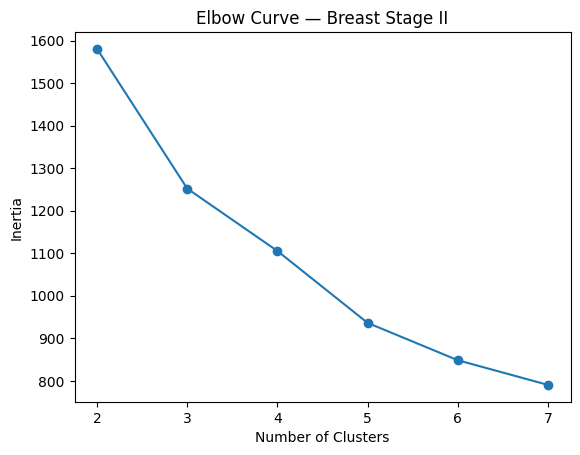

In [53]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Curve — Breast Stage II")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [54]:
kmeans = KMeans(n_clusters=3, random_state=42)
patient_matrix['cluster'] = kmeans.fit_predict(X)

In [55]:
patient_matrix.groupby('cluster')[features].mean()

,time_to_stage,followup,mean_initial,mean_continuing,mean_late,total_cost
cluster,,,,,,
0,-102.524324,770.513514,193.219446,128.538080,167.983358,95004.575060
1,133.468750,1275.843750,476.611841,662.855065,571.157738,512423.530981
2,540.555556,2841.801587,188.175502,149.074471,156.681559,165455.157903


In [56]:
cohort = cohort.merge(
    patient_matrix[['member_number', 'cluster']],
    on='member_number',
    how='left'
)

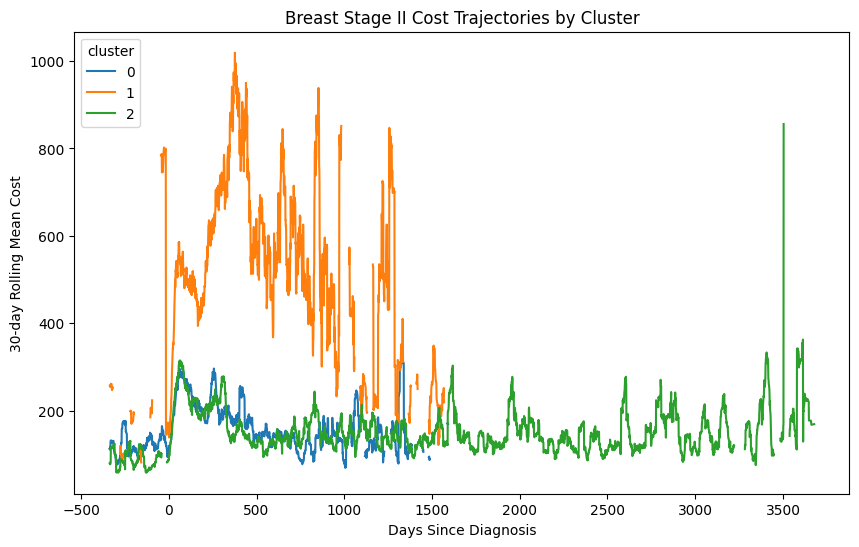

In [57]:
cluster_daily = (
    cohort
    .groupby(['days_since_earliest_dt', 'cluster'])
    .agg(mean_cost=('c_allowed', 'mean'))
    .reset_index()
)

pivot = cluster_daily.pivot(
    index='days_since_earliest_dt',
    columns='cluster',
    values='mean_cost'
)

rolling = pivot.rolling(30).mean()

rolling.plot(figsize=(10,6))
plt.title("Breast Stage II Cost Trajectories by Cluster")
plt.xlabel("Days Since Diagnosis")
plt.ylabel("30-day Rolling Mean Cost")
plt.show()

In [58]:
patient_matrix.groupby('cluster')[
    ['time_to_stage', 'followup', 
     'mean_initial', 'mean_continuing', 
     'mean_late', 'total_cost']
].mean()

,time_to_stage,followup,mean_initial,mean_continuing,mean_late,total_cost
cluster,,,,,,
0,-102.524324,770.513514,193.219446,128.538080,167.983358,95004.575060
1,133.468750,1275.843750,476.611841,662.855065,571.157738,512423.530981
2,540.555556,2841.801587,188.175502,149.074471,156.681559,165455.157903


In [59]:
patient_matrix.groupby('cluster')['time_to_stage'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,185.0,-102.524324,708.879697,-2843.0,0.0,28.0,104.00,1625.0
1,64.0,133.468750,349.286391,-6.0,7.0,21.5,60.25,2075.0
2,126.0,540.555556,658.909214,-474.0,59.0,298.0,898.75,3454.0


### Cluster Summary — Breast Cancer Stage II

To better interpret the utilization patterns identified by the clustering algorithm, we summarize the characteristics of each cluster using the engineered features (time to stage, follow-up duration, phase-specific costs, and total cost) along with the observed cost trajectories.

#### Cluster 0 — Moderate Early Treatment with Gradual Stabilization
This cluster represents patients with **moderate initial treatment costs** that gradually decline and stabilize over time. The mean initial cost (~$193) is slightly higher than the other clusters, but continuing and late-phase costs remain relatively modest. 

Follow-up time for this group averages around **770 days**, indicating moderate observation periods compared to other clusters. The trajectory plot shows an early peak around diagnosis followed by a gradual decline and stabilization. 

This pattern likely reflects **standard treatment pathways** where patients receive initial therapy (such as surgery, chemotherapy, or radiation) followed by routine follow-up care.

---

#### Cluster 1 — High-Intensity Treatment Trajectory
Cluster 1 clearly represents the **highest-cost treatment pathway** in the cohort. Patients in this cluster have dramatically higher costs across all phases of care:

- Initial cost: ~\$477  
- Continuing cost: ~\$663  
- Late-phase cost: ~\$571  
- Mean total cost: **~\$512K**

The trajectory plot shows **sustained high utilization over a long time horizon**, with frequent cost spikes and prolonged elevated spending. Patients in this group also have **longer follow-up periods (~1276 days)**.

This cluster likely represents **patients undergoing intensive or prolonged treatment**, potentially including combination therapies, complications requiring additional care, or repeated treatment cycles.

---

#### Cluster 2 — Long-Term Survivorship / Extended Monitoring
Cluster 2 is characterized by **the longest follow-up duration in the dataset (~2842 days)** but relatively moderate cost levels throughout the care trajectory. 

Initial costs (~\$188) are similar to Cluster 0, but costs remain relatively stable across continuing and late phases. The trajectory plot shows **lower but persistent spending over a much longer timeline**, reflecting ongoing healthcare utilization rather than concentrated treatment episodes.

This pattern may correspond to **long-term survivorship care**, where patients require periodic monitoring, follow-up imaging, endocrine therapy management, or management of long-term treatment effects.

---

### Key Takeaway

Even when restricting the analysis to **the same cancer type (breast) and stage (Stage II)**, patients still fall into **distinct healthcare utilization trajectories**. This suggests that differences in treatment intensity, duration of care, and long-term monitoring drive substantial variation in costs beyond what stage alone can explain.

In particular, the clustering reveals three broad patterns:

1. **Standard treatment with gradual stabilization (Cluster 0)**
2. **High-intensity, high-cost treatment pathways (Cluster 1)**
3. **Long-term survivorship with extended follow-up (Cluster 2)**

These patterns highlight the heterogeneity of cancer care trajectories even within a single stage of disease.

In [62]:
stage_daily = (
    claims_merged
    .groupby('days_from_stage')
    .agg(
        total_cost=('c_allowed', 'sum'),
        unique_members=('member_number', 'nunique')
    )
    .reset_index()
)

stage_daily['cost_per_patient'] = (
    stage_daily['total_cost'] /
    stage_daily['unique_members']
)

stage_daily['rolling_cost'] = (
    stage_daily['cost_per_patient']
    .rolling(30, min_periods=1)
    .mean()
)

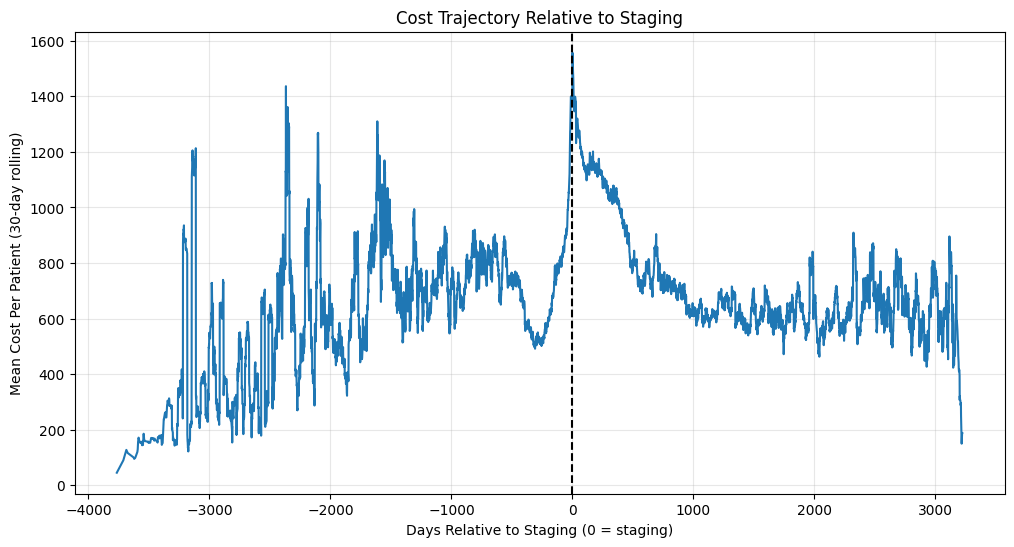

In [63]:
plt.figure(figsize=(12,6))

plt.plot(
    stage_daily['days_from_stage'],
    stage_daily['rolling_cost']
)

plt.axvline(0, linestyle='--', color='black')

plt.title("Cost Trajectory Relative to Staging")
plt.xlabel("Days Relative to Staging (0 = staging)")
plt.ylabel("Mean Cost Per Patient (30-day rolling)")
plt.grid(alpha=0.3)

plt.show()

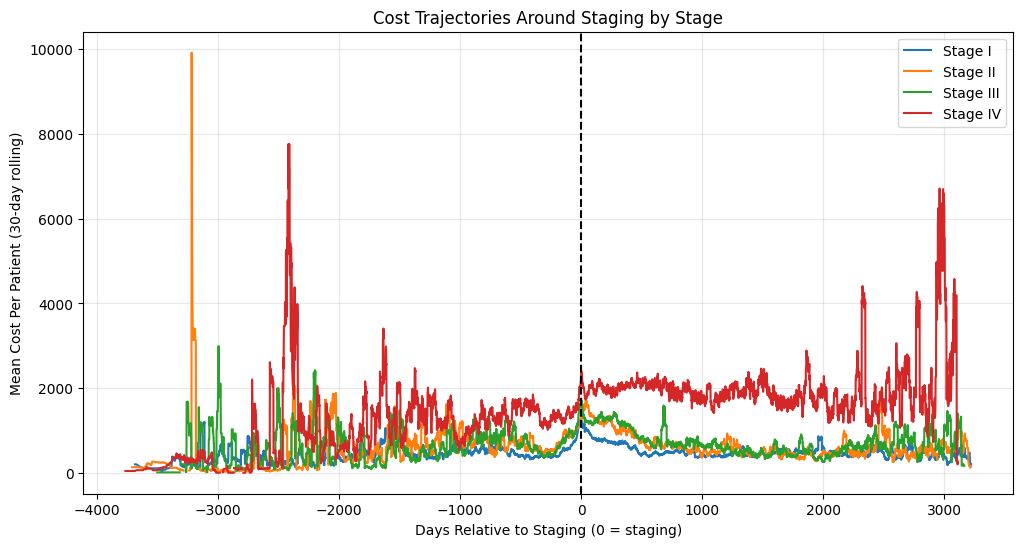

In [65]:
stage_cost = (
    claims_merged
    .groupby(['days_from_stage', 'final_stage_simple'])
    .agg(
        total_cost=('c_allowed', 'sum'),
        unique_members=('member_number', 'nunique')
    )
    .reset_index()
)

stage_cost['cost_per_patient'] = (
    stage_cost['total_cost'] /
    stage_cost['unique_members']
)

pivot = stage_cost.pivot(
    index='days_from_stage',
    columns='final_stage_simple',
    values='cost_per_patient'
)

pivot = pivot.sort_index()

pivot_rolling = pivot.rolling(30, min_periods=1).mean()

plt.figure(figsize=(12,6))

for stage in pivot_rolling.columns:
    plt.plot(
        pivot_rolling.index,
        pivot_rolling[stage],
        label=f"Stage {stage}"
    )

plt.axvline(0, linestyle='--', color='black')

plt.title("Cost Trajectories Around Staging by Stage")
plt.xlabel("Days Relative to Staging (0 = staging)")
plt.ylabel("Mean Cost Per Patient (30-day rolling)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Cost Trajectories Relative to Staging

To better understand how healthcare utilization changes around the staging event, we re-center the patient timeline using `days_from_stage`, which measures the number of days before or after the recorded staging date. In this representation, **day 0 corresponds to the staging event**, negative values represent claims that occurred **before staging**, and positive values represent claims that occurred **after staging**.

#### Overall Cost Pattern

The overall trajectory shows a **clear spike in costs around the staging event**, suggesting that staging often coincides with a period of intensive clinical activity. This likely reflects diagnostic procedures, treatment planning, and the initiation of therapy. Costs tend to **increase in the period leading up to staging**, which may correspond to diagnostic imaging, biopsies, and other workup required to determine disease extent. After staging, costs remain elevated but gradually stabilize as patients transition into ongoing treatment and follow-up care.

#### Differences Across Cancer Stages

When examining trajectories by cancer stage, several patterns emerge:

- **Stage IV patients show the highest and most sustained costs**, both before and after staging. This reflects the more intensive treatment regimens and complex care typically required for advanced disease.
- **Stages II and III exhibit moderate cost levels**, with occasional spikes that may correspond to treatment cycles, complications, or hospitalizations.
- **Stage I patients generally show the lowest costs**, consistent with earlier-stage disease requiring less aggressive treatment.

Across all stages, a **pronounced increase in spending occurs near the staging event**, reinforcing the idea that staging marks a key transition point in the cancer care pathway.

#### Key Takeaway

Centering the timeline on the staging event reveals that **staging is closely associated with a surge in healthcare utilization**, likely reflecting the transition from diagnostic evaluation to active treatment. While overall cost levels vary by stage, the general pattern of **increasing costs leading up to staging followed by sustained treatment-related spending** appears consistent across cancer stages.

In [66]:
cancer_pct = (
    claims_merged['cancer_type']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

cancer_pct.columns = ['cancer_type', 'percentage']

cancer_pct

,cancer_type,percentage
0,breast,58.79
1,colorectal,21.43
2,lung,19.78
